# Few-Shot Claude Highlight Sentiment Classifier

Extends the zero-shot Claude approach (`1_classifier_llm.ipynb`) with **few-shot prompting**
to correct the zero-shot positivity bias (182/200 predicted positive, AUC=0.573).

**Design**:
- Manual 5-fold stratified CV — fold-specific few-shot examples require explicit loop
- For each test fold, sample `k` labeled examples from the *training fold only* (no leakage)
- Stratified sampling: k//2 negative/neutral (<5), k//2 positive (≥5)
- Shot counts tested: k=2, 4, 8
- All k values submitted as a **single batch** — ~1,200 requests, ~50% cost saving vs. sequential
- Cache keys: `fewshot_k{k}_fold{fold}_{task}_{row_id}` — never overwrite zero-shot cache

**Workflow** (4 phases):
1. **Prepare** — build all batch requests for uncached rows
2. **Submit** — send batch, save batch ID to `batch_ids.json` for recovery
3. **Poll** — wait for completion, write results to shared cache
4. **Evaluate** — read from cache, compute metrics (re-runnable without new API calls)

In [8]:
import warnings
warnings.filterwarnings('ignore')

import json
import time
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, roc_auc_score, mean_absolute_error,
    ConfusionMatrixDisplay,
)
import anthropic
from dotenv import dotenv_values

DATA_DIR       = Path('../data-exports/20260412_183830/highlight_analysis_output')
MOD_FILE       = Path('../data-exports/20260412_183830/'
                      'moderation_sessions_export_20260412_183830.csv')
OUT_DIR        = DATA_DIR / 'classifier_output'
OUT_DIR.mkdir(exist_ok=True)

CACHE_FILE     = OUT_DIR / 'llm_predictions_cache.json'   # shared; new keys appended only
BATCH_IDS_FILE = OUT_DIR / 'batch_ids.json'               # recovery: stores submitted batch IDs

RANDOM_STATE   = 42
OUTER_K        = 5
K_VALUES       = [2, 4, 8]
CLAUDE_MODEL   = 'claude-opus-4-7'
POLL_INTERVAL  = 30   # seconds between batch status checks

## Load data and join scenario text

In [9]:
df_sel = pd.read_csv(DATA_DIR / 'df_sel.csv')

mod = pd.read_csv(MOD_FILE)
scenario_text = (
    mod.drop_duplicates('scenario_id')[['scenario_id', 'scenario_prompt', 'original_response']]
)
df = df_sel.merge(scenario_text, on='scenario_id', how='left').reset_index(drop=True)

assert df['scenario_prompt'].isna().sum() == 0
assert df['original_response'].isna().sum() == 0
print(f"df shape: {df.shape}")

df shape: (267, 50)


In [10]:
y_binary     = (df['highlight_sentiment'] >= 5).astype(int).values
y_rating_raw = df['highlight_sentiment'].astype(int).values

print("Binary (0=neg/neutral <5, 1=positive ≥5):", np.bincount(y_binary))

Binary (0=neg/neutral <5, 1=positive ≥5): [ 78 189]


## Claude client and cache helpers

In [11]:
env      = dotenv_values(Path('.') / '.env')
api_key  = env.get('CLAUDE_API_KEY')
base_url = env.get('CLAUDE_API_BASE_URL')

if not api_key:
    print("WARNING: CLAUDE_API_KEY not found in .env — skipping Claude API cells.")
    SKIP_CLAUDE = True
else:
    SKIP_CLAUDE = False
    client = anthropic.Anthropic(api_key=api_key, base_url=base_url)
    print(f"Client ready. Model: {CLAUDE_MODEL}")


def load_cache() -> dict:
    return json.loads(CACHE_FILE.read_text()) if CACHE_FILE.exists() else {}


def save_cache(cache: dict) -> None:
    CACHE_FILE.write_text(json.dumps(cache, indent=2))


def load_batch_ids() -> dict:
    return json.loads(BATCH_IDS_FILE.read_text()) if BATCH_IDS_FILE.exists() else {}


def save_batch_ids(batch_ids: dict) -> None:
    BATCH_IDS_FILE.write_text(json.dumps(batch_ids, indent=2))


cache = load_cache()
print(f"Existing cache entries: {len(cache)}")

Client ready. Model: claude-opus-4-7
Existing cache entries: 400


## System prompts and message helpers

In [12]:
SYSTEM_BINARY = """You are an expert evaluator of AI responses to children's questions.
A parent reviewed an AI chatbot's response to their child's message and highlighted
a specific passage. They then rated that passage on a 1–7 sentiment scale where
1 = very negative or inappropriate for the child and 7 = very positive or appropriate.

Your task is to predict whether the parent rated the highlighted passage as
POSITIVE (rating ≥5) or NEGATIVE/NEUTRAL (rating < 5).

You will be given labeled examples to calibrate your predictions, followed by a new case.

Respond ONLY with a JSON object in this exact format, no other text:
{"prediction": 0 or 1, "confidence": 0.0 to 1.0}

Where prediction=1 means POSITIVE sentiment (≥5) and prediction=0 means NEGATIVE/NEUTRAL (<5).
Confidence is your certainty from 0.0 (random guess) to 1.0 (certain)."""

SYSTEM_RATING = """You are an expert evaluator of AI responses to children's questions.
A parent reviewed an AI chatbot's response to their child's message and highlighted
a specific passage. They then rated that passage on a 1–7 sentiment scale where:
1 = very negative or inappropriate for a child (harmful, misleading, or concerning)
4 = neutral (neither clearly good nor bad)
7 = very positive or appropriate for a child (helpful, safe, and well-suited)

Your task is to predict the parent's sentiment rating for the highlighted passage.

You will be given labeled examples to calibrate your predictions, followed by a new case.

Respond ONLY with a JSON object in this exact format, no other text:
{\"rating\": <integer 1-7>}"""


def make_case_block(row: pd.Series) -> str:
    return (
        f"AGE BAND: {row.get('age_band', 'unknown')}\n"
        f"DOMAIN: {row.get('domain', 'unknown')}\n\n"
        f"CHILD'S QUESTION:\n{row['scenario_prompt']}\n\n"
        f"FULL AI RESPONSE:\n{row['original_response']}\n\n"
        f"HIGHLIGHTED TEXT:\n{row['highlight_text']}"
    )


def make_fewshot_prefix(df_train: pd.DataFrame, k: int, random_state: int = 42) -> str:
    neg = df_train[df_train['highlight_sentiment'] < 5]
    pos = df_train[df_train['highlight_sentiment'] >= 5]
    k_neg, k_pos = k // 2, k - k // 2
    neg_s = neg.sample(n=k_neg, replace=len(neg) < k_neg, random_state=random_state)
    pos_s = pos.sample(n=k_pos, replace=len(pos) < k_pos, random_state=random_state)
    examples = pd.concat([neg_s, pos_s]).sample(frac=1, random_state=random_state)

    parts = ["EXAMPLES (use these to calibrate your prediction of the parent's sentiment rating):\n"]
    for i, (_, row) in enumerate(examples.iterrows(), 1):
        rating = int(row['highlight_sentiment'])
        label  = 'POSITIVE (≥5)' if rating >= 5 else 'NEGATIVE/NEUTRAL (<5)'
        parts.append(f"[EXAMPLE {i} — TRUE RATING: {rating} ({label})]\n" + make_case_block(row))
    parts.append("\nNow predict for the following new case:")
    return "\n\n".join(parts)

## Phase 1 — Prepare batch requests

Iterates over all folds × k values × tasks, builds a batch request for every
uncached (cache_key, message) pair. All k values are bundled into one batch.

In [13]:
def prepare_fewshot_requests(
    df: pd.DataFrame,
    y_binary: np.ndarray,
    k_values: list[int],
    cache: dict,
    outer_k: int = OUTER_K,
) -> list[dict]:
    """
    Build Batch API request objects for all uncached (k, fold, task, row) combinations.
    Returns a list ready to pass to client.messages.batches.create(requests=...).
    """
    skf      = StratifiedKFold(n_splits=outer_k, shuffle=True, random_state=RANDOM_STATE)
    requests = []

    for k in k_values:
        for fold_idx, (train_idx, test_idx) in enumerate(
            skf.split(np.zeros(len(df)), y_binary)
        ):
            prefix   = make_fewshot_prefix(df.iloc[train_idx], k,
                                            random_state=fold_idx * 100 + k)
            df_test  = df.iloc[test_idx]

            for pos, (_, row) in zip(test_idx, df_test.iterrows()):
                user_msg = prefix + "\n\n" + make_case_block(row)

                for task, system in [
                    ('binary', SYSTEM_BINARY),
                    ('rating', SYSTEM_RATING),
                ]:
                    key = f"fewshot_k{k}_fold{fold_idx}_{task}_pos{pos}"
                    if key not in cache:
                        requests.append({
                            "custom_id": key,
                            "params": {
                                "model":      CLAUDE_MODEL,
                                "max_tokens": 64,
                                "system": [{
                                    "type": "text",
                                    "text": system,
                                    "cache_control": {"type": "ephemeral"},
                                }],
                                "messages": [{"role": "user", "content": user_msg}],
                            },
                        })

    return requests


if not SKIP_CLAUDE:
    cache    = load_cache()
    requests = prepare_fewshot_requests(df, y_binary, K_VALUES, cache)
    print(f"Requests to submit: {len(requests)}  (already cached: "
          f"{len(K_VALUES) * OUTER_K * len(df) * 2 - len(requests)})")

Requests to submit: 1602  (already cached: 6408)


## Phase 2 — Submit batch

Submits all requests as a single batch. The batch ID is saved to `batch_ids.json`
so the poll cell can be re-run independently if the notebook is interrupted.

In [14]:
if not SKIP_CLAUDE and requests:
    batch      = client.messages.batches.create(requests=requests)
    batch_id   = batch.id

    batch_ids  = load_batch_ids()
    batch_ids['fewshot'] = batch_id
    save_batch_ids(batch_ids)

    print(f"Batch submitted: {batch_id}")
    print(f"Requests: {len(requests)}  |  Status: {batch.processing_status}")
elif not SKIP_CLAUDE:
    print("All requests already cached — skipping submission.")
    batch_id = load_batch_ids().get('fewshot')

Batch submitted: msgbatch_01NbKdkpYCAyhEvjgPqZps8H
Requests: 1602  |  Status: in_progress


## Phase 3 — Poll until complete, write results to cache

Re-runnable: loads `batch_id` from `batch_ids.json` if `batch_id` is not in scope.
Polls every `POLL_INTERVAL` seconds. Once ended, parses all results and appends
them to the shared cache file.

In [15]:
if not SKIP_CLAUDE:
    # Recover batch_id if this cell is run in a fresh session
    if 'batch_id' not in dir() or batch_id is None:
        batch_id = load_batch_ids().get('fewshot')
        if not batch_id:
            raise RuntimeError("No batch_id found — run the submit cell first.")
        print(f"Recovered batch_id from file: {batch_id}")

    print(f"Polling batch {batch_id} every {POLL_INTERVAL}s…")
    while True:
        batch  = client.messages.batches.retrieve(batch_id)
        counts = batch.request_counts
        print(f"  {batch.processing_status} — "
              f"processing={counts.processing}  "
              f"succeeded={counts.succeeded}  "
              f"errored={counts.errored}")
        if batch.processing_status == 'ended':
            break
        time.sleep(POLL_INTERVAL)

    # Parse results and update cache
    cache    = load_cache()
    n_ok, n_err = 0, 0
    for result in client.messages.batches.results(batch_id):
        if result.result.type == 'succeeded':
            try:
                cache[result.custom_id] = json.loads(
                    result.result.message.content[0].text.strip()
                )
                n_ok += 1
            except Exception:
                cache[result.custom_id] = None
                n_err += 1
        else:
            cache[result.custom_id] = None
            n_err += 1

    save_cache(cache)
    print(f"\nCache updated: {n_ok} succeeded, {n_err} failed. Total entries: {len(cache)}")

Polling batch msgbatch_01NbKdkpYCAyhEvjgPqZps8H every 30s…
  in_progress — processing=1602  succeeded=0  errored=0
  in_progress — processing=1602  succeeded=0  errored=0
  in_progress — processing=1602  succeeded=0  errored=0
  in_progress — processing=1602  succeeded=0  errored=0
  in_progress — processing=1602  succeeded=0  errored=0
  in_progress — processing=1602  succeeded=0  errored=0
  ended — processing=0  succeeded=1602  errored=0

Cache updated: 1602 succeeded, 0 failed. Total entries: 2002


## Phase 4 — Extract predictions from cache

In [16]:
def extract_fewshot_predictions(
    df: pd.DataFrame,
    y_binary: np.ndarray,
    k: int,
    cache: dict,
    outer_k: int = OUTER_K,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Read predictions from cache for a given k. Falls back to majority/5 on missing."""
    skf          = StratifiedKFold(n_splits=outer_k, shuffle=True, random_state=RANDOM_STATE)
    binary_preds = np.ones(len(df), dtype=int)
    binary_conf  = np.full(len(df), 0.5)
    rating_preds = np.full(len(df), 5, dtype=int)

    for fold_idx, (_, test_idx) in enumerate(skf.split(np.zeros(len(df)), y_binary)):
        for pos in test_idx:
            b = cache.get(f"fewshot_k{k}_fold{fold_idx}_binary_pos{pos}")
            if b and 'prediction' in b:
                binary_preds[pos] = int(b['prediction'])
                binary_conf[pos]  = float(b.get('confidence', 0.5))

            r = cache.get(f"fewshot_k{k}_fold{fold_idx}_rating_pos{pos}")
            if r and 'rating' in r:
                rating_preds[pos] = int(np.clip(r['rating'], 1, 7))

    return binary_preds, binary_conf, rating_preds


if not SKIP_CLAUDE:
    cache = load_cache()
    fewshot_results = {}
    for k in K_VALUES:
        bp, bc, rp = extract_fewshot_predictions(df, y_binary, k, cache)
        fewshot_results[k] = {'binary_preds': bp, 'binary_conf': bc, 'rating_preds': rp}
        n_cached = sum(
            1 for key in cache
            if key.startswith(f'fewshot_k{k}_') and '_binary_' in key
        )
        print(f"k={k}: {n_cached}/200 binary predictions in cache")

k=2: 267/200 binary predictions in cache
k=4: 267/200 binary predictions in cache
k=8: 267/200 binary predictions in cache


## Evaluate — binary task

In [17]:
if not SKIP_CLAUDE:
    binary_rows = []
    for k in K_VALUES:
        bp = fewshot_results[k]['binary_preds']
        bc = fewshot_results[k]['binary_conf']
        binary_rows.append({
            'k':            k,
            'n_positive':   int(bp.sum()),
            'F1':           round(f1_score(y_binary, bp), 3),
            'AUC (conf)':   round(roc_auc_score(y_binary, bc), 3),
            'AUC (binary)': round(roc_auc_score(y_binary, bp), 3),
        })

    binary_df = pd.DataFrame(binary_rows)
    print("Few-shot binary results (n=200):")
    print(binary_df.to_string(index=False))
    print("\nBaseline: zero-shot AUC=0.573, F1=0.821, n_positive=182")
    binary_df.to_csv(OUT_DIR / 'cv_fewshot_binary.csv', index=False)

Few-shot binary results (n=200):
 k  n_positive    F1  AUC (conf)  AUC (binary)
 2         212 0.823       0.527         0.635
 4         211 0.805       0.562         0.605
 8         210 0.812       0.578         0.621

Baseline: zero-shot AUC=0.573, F1=0.821, n_positive=182


## Evaluate — rating task

In [18]:
if not SKIP_CLAUDE:
    rating_rows = []
    for k in K_VALUES:
        rp   = fewshot_results[k]['rating_preds']
        rating_rows.append({
            'k':         k,
            'pred_mean': round(rp.mean(), 2),
            'MAE':       round(mean_absolute_error(y_rating_raw, rp), 3),
            'Pearson r': round(np.corrcoef(y_rating_raw, rp)[0, 1], 3),
        })

    rating_df = pd.DataFrame(rating_rows)
    print("Few-shot rating results (n=200, true mean=5.33):")
    print(rating_df.to_string(index=False))
    rating_df.to_csv(OUT_DIR / 'cv_fewshot_rating.csv', index=False)

Few-shot rating results (n=200, true mean=5.33):
 k  pred_mean   MAE  Pearson r
 2       5.35 1.442      0.293
 4       5.38 1.393      0.331
 8       5.30 1.419      0.327


## Confusion matrices — all k

Best k by AUC (conf): 8


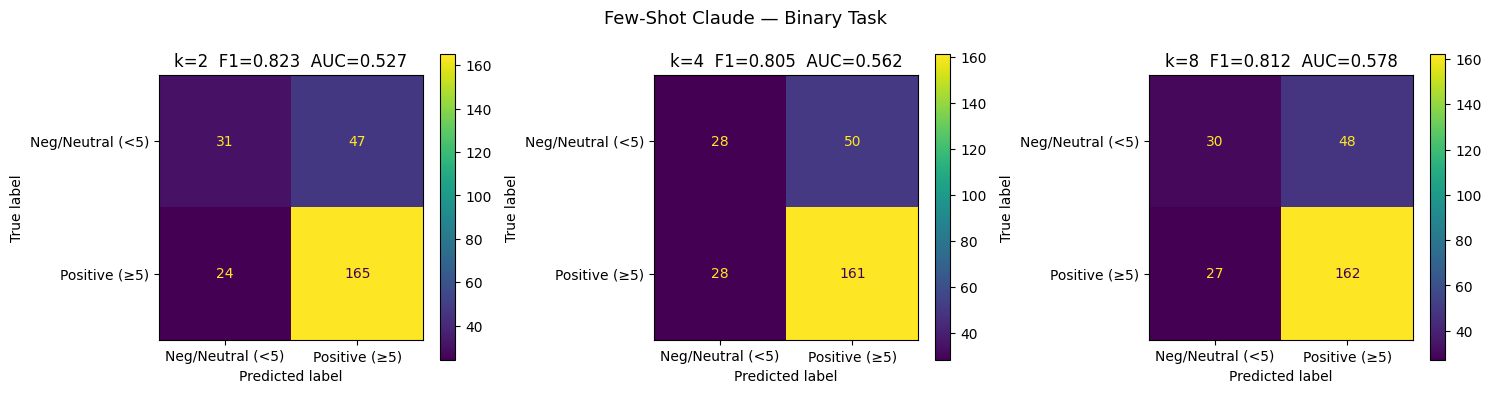

In [19]:
if not SKIP_CLAUDE:
    best_k = binary_df.loc[binary_df['AUC (conf)'].idxmax(), 'k']
    print(f"Best k by AUC (conf): {best_k}")

    fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5 * len(K_VALUES), 4))
    for ax, k in zip(axes, K_VALUES):
        bp  = fewshot_results[k]['binary_preds']
        bc  = fewshot_results[k]['binary_conf']
        f1  = f1_score(y_binary, bp)
        auc = roc_auc_score(y_binary, bc)
        ConfusionMatrixDisplay.from_predictions(
            y_binary, bp,
            display_labels=['Neg/Neutral (<5)', 'Positive (≥5)'], ax=ax,
        )
        ax.set_title(f'k={k}  F1={f1:.3f}  AUC={auc:.3f}')

    plt.suptitle('Few-Shot Claude — Binary Task', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fewshot_confusion_matrices.png', dpi=100)
    plt.show()

## Prediction distribution by k

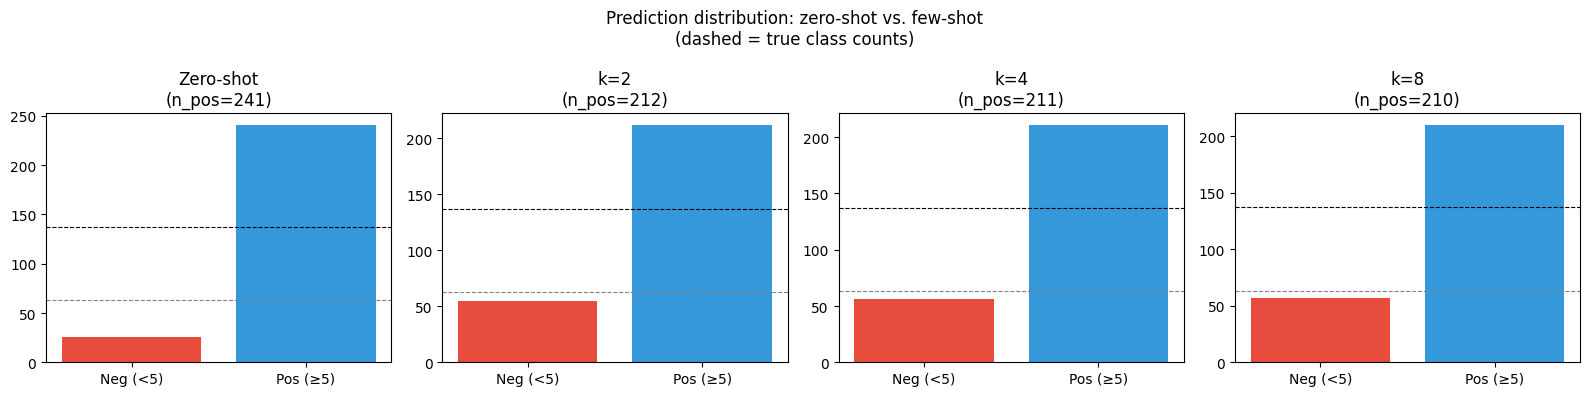

In [20]:
if not SKIP_CLAUDE:
    # Zero-shot reference from 1_classifier_llm cache
    zs_preds = np.array([
        int(cache.get(f'binary_{row["selection_id"]}', {}).get('prediction', 1))
        for _, row in df.iterrows()
    ])

    fig, axes = plt.subplots(1, len(K_VALUES) + 1, figsize=(4 * (len(K_VALUES) + 1), 4))
    for ax, (label, bp) in zip(axes, [('Zero-shot', zs_preds)] +
                                     [(f'k={k}', fewshot_results[k]['binary_preds'])
                                      for k in K_VALUES]):
        ax.bar(['Neg (<5)', 'Pos (≥5)'],
               [(bp == 0).sum(), (bp == 1).sum()],
               color=['#e74c3c', '#3498db'])
        ax.set_title(f'{label}\n(n_pos={bp.sum()})')
        ax.axhline(63,  color='gray',  linestyle='--', linewidth=0.8)
        ax.axhline(137, color='black', linestyle='--', linewidth=0.8)

    plt.suptitle('Prediction distribution: zero-shot vs. few-shot\n(dashed = true class counts)',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fewshot_prediction_distribution.png', dpi=100)
    plt.show()

## Consolidated results table

In [21]:
if not SKIP_CLAUDE:
    rows = []
    try:
        for _, r in pd.read_csv(OUT_DIR / 'cv_binary.csv').iterrows():
            if pd.isna(r.get('error', None)):
                rows.append({'approach': 'Structured (A+B+C)', 'model': r['model'],
                             'F1': f"{r['f1_mean']:.3f} ± {r['f1_std']:.3f}",
                             'AUC': f"{r['roc_auc_mean']:.3f} ± {r['roc_auc_std']:.3f}"})
    except FileNotFoundError:
        print("cv_binary.csv not found — run 1_classifier_sentiment.ipynb first.")

    zs_f1  = f1_score(y_binary, zs_preds)
    zs_auc = roc_auc_score(y_binary, zs_preds)
    rows.append({'approach': 'Claude zero-shot', 'model': 'zero-shot',
                 'F1': f"{zs_f1:.3f}", 'AUC': f"{zs_auc:.3f}"})

    for k in K_VALUES:
        bp = fewshot_results[k]['binary_preds']
        bc = fewshot_results[k]['binary_conf']
        rows.append({'approach': f'Claude few-shot (k={k})', 'model': f'few-shot k={k}',
                     'F1': f"{f1_score(y_binary, bp):.3f}",
                     'AUC': f"{roc_auc_score(y_binary, bc):.3f}"})

    consolidated = pd.DataFrame(rows)
    print(consolidated.to_string(index=False))
    consolidated.to_csv(OUT_DIR / 'consolidated_fewshot_binary.csv', index=False)

             approach               model            F1           AUC
   Structured (A+B+C)   Majority Baseline 0.813 ± 0.009 0.500 ± 0.000
   Structured (A+B+C) Stratified Baseline 0.709 ± 0.034 0.497 ± 0.057
   Structured (A+B+C) Logistic Regression 0.865 ± 0.031 0.858 ± 0.056
   Structured (A+B+C)         Naive Bayes 0.797 ± 0.054 0.808 ± 0.061
   Structured (A+B+C)       Decision Tree 0.850 ± 0.043 0.804 ± 0.057
   Structured (A+B+C)       Random Forest 0.860 ± 0.046 0.876 ± 0.031
   Structured (A+B+C)            LightGBM 0.839 ± 0.021 0.844 ± 0.010
   Structured (A+B+C)        SVM (linear) 0.867 ± 0.043 0.857 ± 0.071
     Claude zero-shot           zero-shot         0.823         0.558
Claude few-shot (k=2)        few-shot k=2         0.823         0.527
Claude few-shot (k=4)        few-shot k=4         0.805         0.562
Claude few-shot (k=8)        few-shot k=8         0.812         0.578
